# 2. Feature Engineering

Extract KPIs, embeddings, and process statistics.

## 2.0 Install Dependencies

In [1]:
# Install required packages (safe to re-run; --quiet suppresses noise)
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
    'pandas',
    'pyarrow',
    'numpy',
    'scikit-learn',
    'joblib',
    'matplotlib',
    'seaborn',
    'sentence-transformers',
])


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: /mnt/hdd/Code/Git/bwa/.venv/bin/python -m pip install --upgrade pip


0

## 2.1 Setup

In [2]:
import sys; from pathlib import Path
_here = Path.cwd()
for _p in [_here, *_here.parents]:
    if (_p / 'src' / 'data_ingestion.py').exists():
        _repo_root = _p
        _src = str(_p / 'src')
        if _src not in sys.path: sys.path.insert(0, _src)
        break
DATASET = "BPIC2012"
OUTPUT_DIR = _repo_root / 'output' / DATASET
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2.1 Load Data

In [3]:
import pandas as pd
df = pd.read_parquet(OUTPUT_DIR / f'events_{DATASET}_train.parquet')
print(f"Loaded {len(df)} events")

Loaded 262200 events


## 2.2 Compute KPIs

In [4]:
from feature_engineering import compute_case_kpis
kpis = compute_case_kpis(df)
kpis.to_parquet(OUTPUT_DIR / f'kpis_{DATASET}_train.parquet', engine='pyarrow', index=False)
print('KPIs saved')

KPIs saved


## 2.3 Transition Matrix

In [5]:
from feature_engineering import compute_transition_matrix
trans_mat = compute_transition_matrix(df)
trans_mat.to_parquet(OUTPUT_DIR / f'transition_matrix_{DATASET}_train.parquet', engine='pyarrow')
print('Transition matrix saved')

Transition matrix saved


## 2.4 Activity Embeddings

In [6]:
from feature_engineering import ActivityEmbedder
import joblib, math

# Scale embed_dim with dataset size so the embedding space is large enough
# to represent all activities. Formula: next power-of-2 >= sqrt(n_acts)*4,
# clamped to [32, 128]. Matches the formula used in notebook 04.
_n_acts = df['activity'].nunique()
_embed_dim = int(min(128, max(32, 2 ** math.ceil(math.log2(max(32, int(math.sqrt(_n_acts) * 4)))))))
print(f'Activities: {_n_acts}  →  embed_dim: {_embed_dim}')

embedder = ActivityEmbedder(vector_size=_embed_dim, seed=42)
embedder.fit(df)
joblib.dump(embedder, OUTPUT_DIR / f'activity_embeddings.model')
print('Embeddings saved')

Activities: 24  →  embed_dim: 32


Embeddings saved


## 2.5 Terminal Classification

Classifies which activities represent bad terminal states (rejection, cancellation)
using semantic sentence embeddings (`all-MiniLM-L6-v2`). Runs once here and
saves the result so `ProcessEnv` can load it instantly without re-downloading
the model on every instantiation.

In [7]:
from feature_engineering import classify_bad_terminals, classify_good_terminals
import json

activities = sorted(df['activity'].unique().tolist())
bad_terminals  = classify_bad_terminals(activities)
good_terminals = classify_good_terminals(df, bad_terminals)

terminal_info = {
    'activities':     activities,
    'bad_terminals':  sorted(bad_terminals),
    'good_terminals': sorted(good_terminals),
}
with open(OUTPUT_DIR / 'terminal_classification.json', 'w') as f:
    json.dump(terminal_info, f, indent=2)

print(f'Bad terminals:  {sorted(bad_terminals)}')
print(f'Good terminals: {sorted(good_terminals)}')
print(f'Saved to {OUTPUT_DIR / "terminal_classification.json"}')

/mnt/hdd/Code/Git/bwa/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|                                              | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|█████████████████████████████████| 103/103 [00:00<00:00, 11375.66it/s]

Bad terminals:  ['A_CANCELLED', 'A_DECLINED', 'O_CANCELLED', 'O_DECLINED']
Good terminals: ['A_ACCEPTED', 'A_APPROVED', 'A_FINALIZED', 'A_PREACCEPTED', 'O_ACCEPTED']
Saved to /mnt/hdd/Code/Git/bwa/output/BPIC2012/terminal_classification.json


## 2.5 Visualization

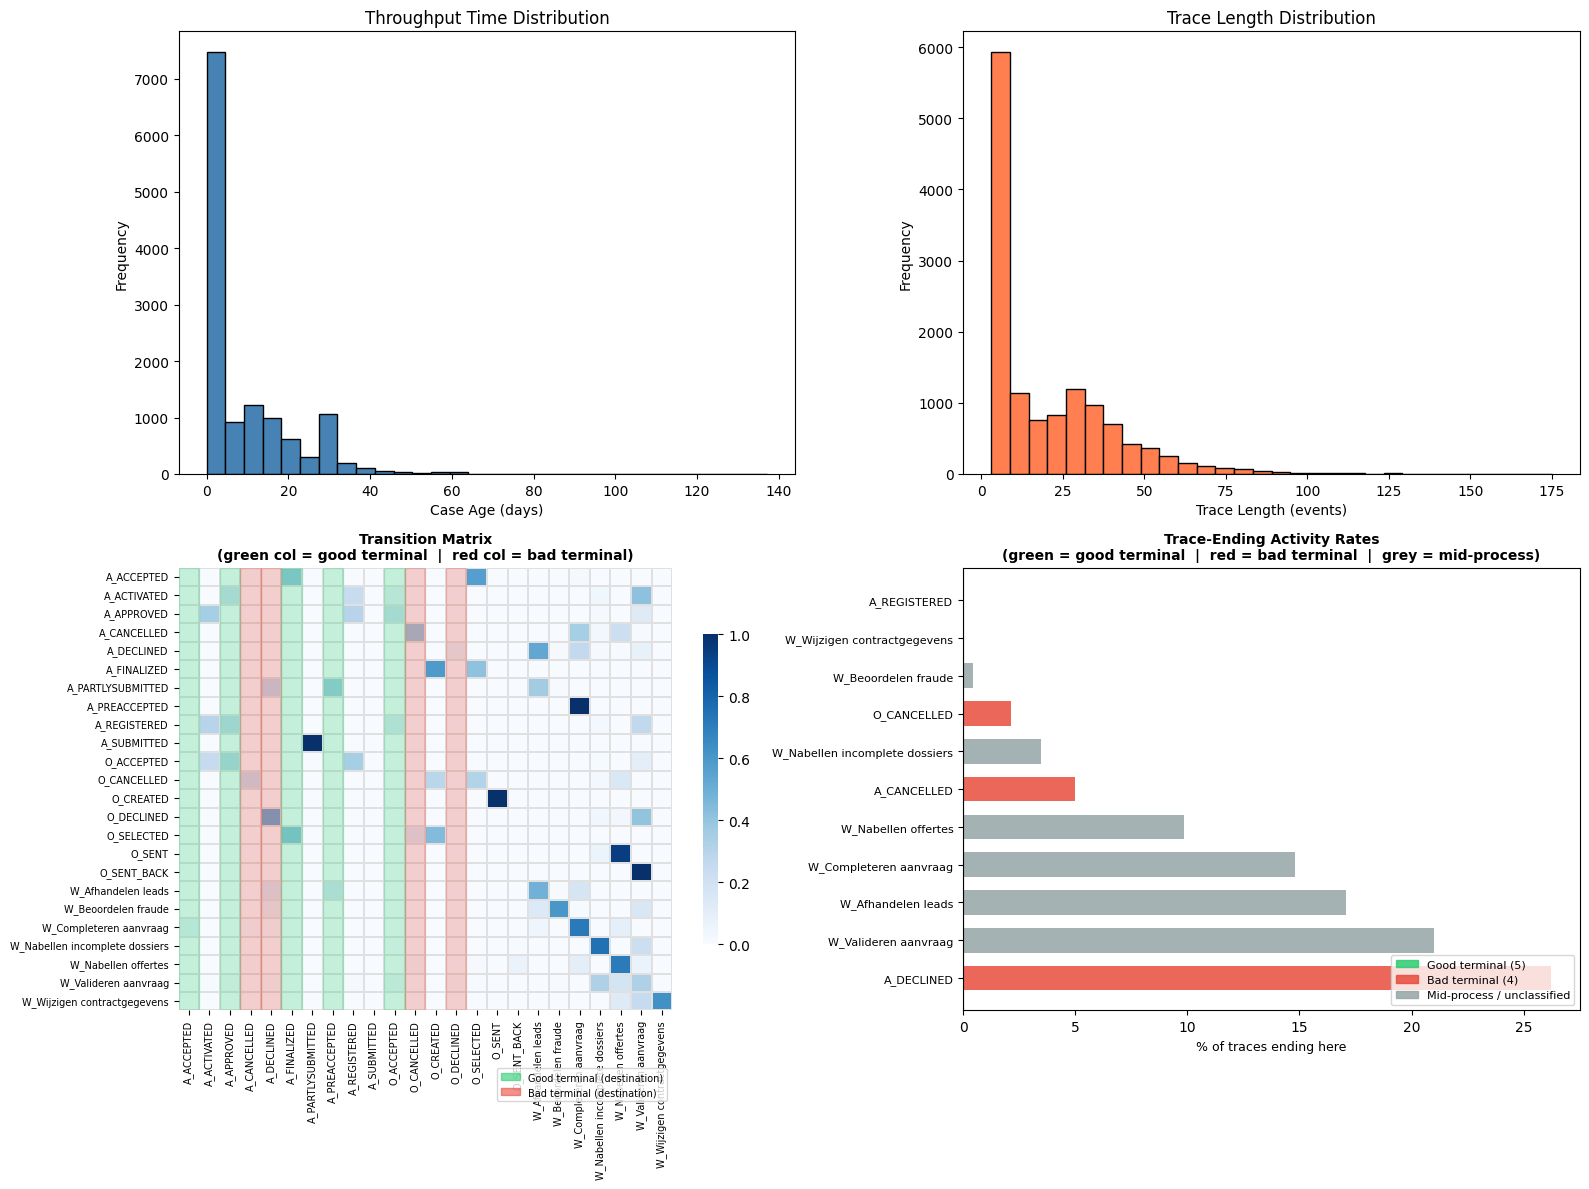

Saved to /mnt/hdd/Code/Git/bwa/output/BPIC2012/feature_engineering_overview.png
Good terminals: ['A_ACCEPTED', 'A_APPROVED', 'A_FINALIZED', 'A_PREACCEPTED', 'O_ACCEPTED']
Bad terminals:  ['A_CANCELLED', 'A_DECLINED', 'O_CANCELLED', 'O_DECLINED']


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# Load terminal classification
import json
_tc = json.load(open(OUTPUT_DIR / 'terminal_classification.json'))
_bad_terminals  = set(_tc.get('bad_terminals', []))
_good_terminals = set(_tc.get('good_terminals', []))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── [0,0] Throughput time distribution ───────────────────────────────────────
kpis = pd.read_parquet(OUTPUT_DIR / f'kpis_{DATASET}_train.parquet')
axes[0, 0].hist(kpis['case_age_days'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Case Age (days)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Throughput Time Distribution')

# ── [0,1] Trace length distribution ──────────────────────────────────────────
axes[0, 1].hist(kpis['trace_length'], bins=30, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Trace Length (events)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Trace Length Distribution')

# ── [1,0] Transition heatmap with good/bad terminal overlays ─────────────────
trans_mat = pd.read_parquet(OUTPUT_DIR / f'transition_matrix_{DATASET}_train.parquet', engine='pyarrow')
if not trans_mat.empty:
    ax_hm = axes[1, 0]
    sns.heatmap(trans_mat, ax=ax_hm, cmap='Blues', annot=False,
                linewidths=0.3, linecolor='#e0e0e0', cbar_kws={'shrink': 0.7})
    ax_hm.set_title('Transition Matrix\n(green col = good terminal  |  red col = bad terminal)',
                    fontsize=10, fontweight='bold')
    ax_hm.tick_params(axis='both', labelsize=7)

    # Highlight columns that are good/bad terminals
    cols = list(trans_mat.columns)
    rows = list(trans_mat.index)
    for j, col in enumerate(cols):
        if col in _bad_terminals:
            ax_hm.add_patch(plt.Rectangle((j, 0), 1, len(rows),
                            fill=True, color='#e74c3c', alpha=0.25, zorder=3))
        elif col in _good_terminals:
            ax_hm.add_patch(plt.Rectangle((j, 0), 1, len(rows),
                            fill=True, color='#2ecc71', alpha=0.25, zorder=3))

    legend_handles = [
        mpatches.Patch(color='#2ecc71', alpha=0.6, label='Good terminal (destination)'),
        mpatches.Patch(color='#e74c3c', alpha=0.6, label='Bad terminal (destination)'),
    ]
    ax_hm.legend(handles=legend_handles, fontsize=7, loc='upper right',
                 bbox_to_anchor=(1.0, -0.12), ncol=1)
else:
    axes[1, 0].text(0.5, 0.5, 'Transition matrix empty', ha='center', va='center')
    axes[1, 0].set_title('Transition Matrix')

# ── [1,1] Terminal classification bar chart ───────────────────────────────────
# Show empirical trace-ending rate per activity, coloured by terminal type.
ax_tc = axes[1, 1]
last_acts = (
    df.sort_values(['case_id', 'timestamp'])
    .groupby('case_id')['activity']
    .last()
)
end_rates = (last_acts.value_counts() / len(last_acts)).head(15)

bar_colors = []
for act in end_rates.index:
    if act in _bad_terminals:
        bar_colors.append('#e74c3c')
    elif act in _good_terminals:
        bar_colors.append('#2ecc71')
    else:
        bar_colors.append('#95a5a6')

y_pos = np.arange(len(end_rates))
ax_tc.barh(y_pos, end_rates.values * 100, color=bar_colors, alpha=0.85, height=0.65)
ax_tc.set_yticks(y_pos)
ax_tc.set_yticklabels(end_rates.index, fontsize=8)
ax_tc.set_xlabel('% of traces ending here', fontsize=9)
ax_tc.set_title('Trace-Ending Activity Rates\n(green = good terminal  |  red = bad terminal  |  grey = mid-process)',
                fontsize=10, fontweight='bold')
ax_tc.axvline(0, color='#555', lw=0.8)

legend_handles2 = [
    mpatches.Patch(color='#2ecc71', alpha=0.85, label=f'Good terminal ({len(_good_terminals)})'),
    mpatches.Patch(color='#e74c3c', alpha=0.85, label=f'Bad terminal ({len(_bad_terminals)})'),
    mpatches.Patch(color='#95a5a6', alpha=0.85, label='Mid-process / unclassified'),
]
ax_tc.legend(handles=legend_handles2, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_engineering_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_DIR / 'feature_engineering_overview.png'}")
print(f"Good terminals: {sorted(_good_terminals)}")
print(f"Bad terminals:  {sorted(_bad_terminals)}")